In [128]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../mtcars.csv')

In [ ]:
# 다음 DataFrame methods을 사용해서 데이터셋의 결과를 출력하세요.

# head, tail
print("head, tail 실습 ----------------------------------------")
print(df.head())
print(df.tail())
# shape
# shape method를 이용해서 데이터의 갯수 (row count)를 출력하세요.
print("shape 실습 ----------------------------------------")
print(df.shape[0])
# columns
# 데이터셋의 컬럼 중 이름이 없는 컬럼을 찾아서 적합한 이름으로 변경하세요.
print("columns 실습 ----------------------------------------")
print(df.rename(columns={'Unnamed: 0': 'Car_name'}))
# info, dtypes
print("info 실습 ----------------------------------------")
print(df.info())
print("dtypes 실습 ----------------------------------------")
print(df.dtypes)
# describe
print("describe 실습 ----------------------------------------")
print(df.describe())

head, tail 실습 ----------------------------------------
          Unnamed: 0   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
0          Mazda RX4  21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
1      Mazda RX4 Wag  21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
2         Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
3     Hornet 4 Drive  21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
4  Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

   carb  
0     4  
1     4  
2     1  
3     1  
4     2  
        Unnamed: 0   mpg  cyl   disp   hp  drat     wt  qsec  vs  am  gear  \
27    Lotus Europa  30.4    4   95.1  113  3.77  1.513  16.9   1   1     5   
28  Ford Pantera L  15.8    8  351.0  264  4.22  3.170  14.5   0   1     5   
29    Ferrari Dino  19.7    6  145.0  175  3.62  2.770  15.5   0   1     5   
30   Maserati Bora  15.0    8  301.0  335  3.54  3.570  14.6   0   1     5   
31      

In [91]:
#gear, transmission features에는 각각 몇가지 값이 있는지를 출력하세요.
print(df["gear"].nunique())
print(df["am"].nunique())

3
2


gear  am
3     0     15
4     1      8
5     1      5
4     0      4
Name: count, dtype: int64


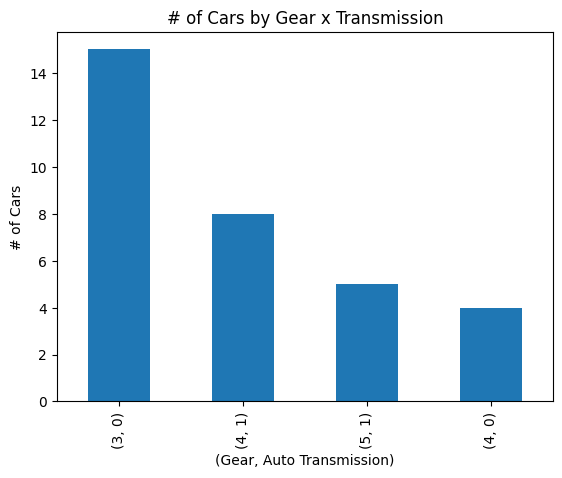

In [ ]:
#gear와 transmission의 경우의 수 조합별로 나누고 각 조합에 몇개의 차량이 있는지를 알아내세요.
# 먼저 결과값을 화면에 출력하세요.
# 결과값을 바 그래프로 그리세요. 타이틀은 '# of Cars by Gear x Transmission'로, x축 레이블은 '(Gear, Auto Transmission)', y축 레이블은 '# of Cars'로 만드세요.

print(df[['gear','am']].value_counts())

df[['gear','am']].value_counts().plot(kind="bar")
plt.title('# of Cars by Gear x Transmission')
plt.xlabel("(Gear, Auto Transmission)")
plt.ylabel("# of Cars")
plt.show()

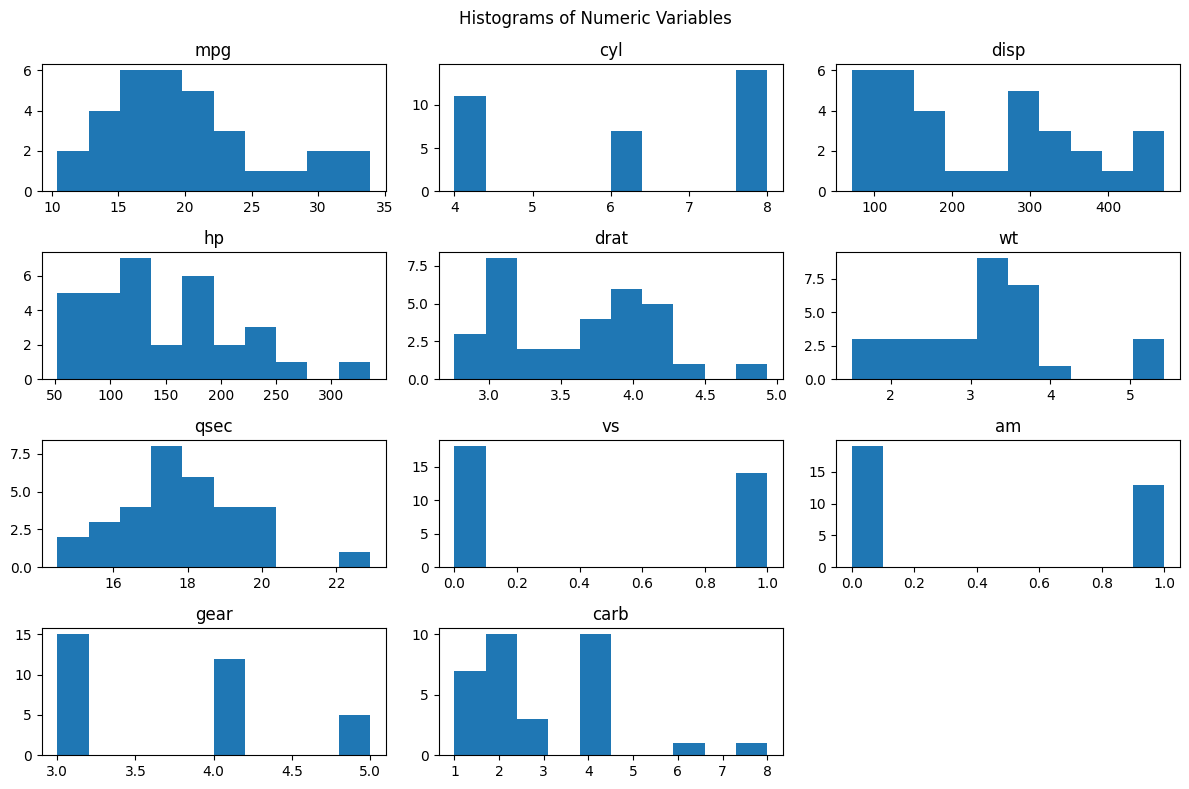

In [ ]:
# 데이터셋에 포함된 모든 features의 히스토그램을 그리세요.
# 그래프 타이틀은 "Histograms of Variables"로 하세요.
# 최대한 잘 보이도록 그래프들을 배치하세요.

import math

num_cols = df.select_dtypes(include=['number']).columns
fig, axes = plt.subplots(math.ceil(len(num_cols) / 3), 3, figsize=(12, 8))

for ax, col in zip(axes.flat, num_cols):
    ax.hist(df[col])
    ax.set_title(col)

for i in range(len(num_cols), len(axes.flat)):
    fig.delaxes(axes.flat[i])

fig.suptitle("Histograms of Numeric Variables")
plt.tight_layout()
plt.show()

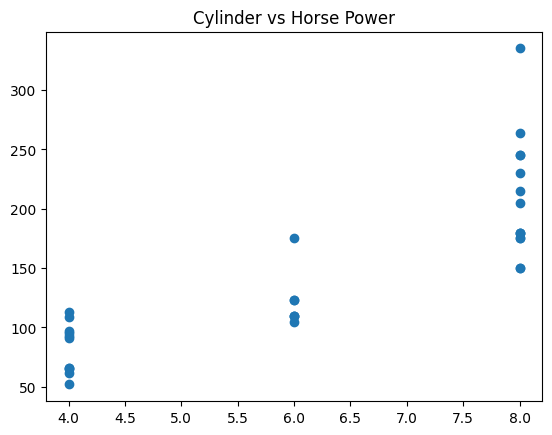

In [ ]:
# Cylinder와 HorsePower 간의 상관 관계를 알아보기 위해 scatter 차트를 그리세요.
# 그래프 타이틀은 "Cylinder vs Horse Power"로 하세요.

x = df["cyl"]
y = df["hp"]

plt.scatter(x,y)
plt.title("Cylinder vs Horse Power")
plt.show()

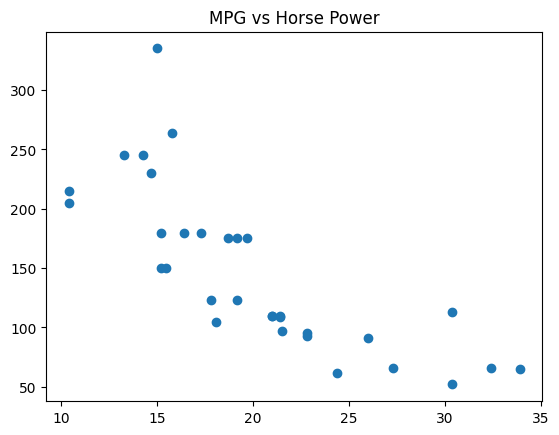

In [ ]:
# MPG와 HorsePower 간의 상관 관계를 알아보기 위해 scatter 차트를 그리세요.
# 그래프 타이틀은 "MPG vs Horse Power"로 하세요.

x = df["mpg"]
y = df["hp"]

plt.scatter(x,y)
plt.title("MPG vs Horse Power")
plt.show()

In [129]:
#각 변수들 간의 상관 관계를 알아 보기 위해 상관계수를 구하는 표를 출력하세요.
corr_matrix = df.select_dtypes(include=['number']).corr()

print(corr_matrix)


           mpg       cyl      disp        hp      drat        wt      qsec  \
mpg   1.000000 -0.852162 -0.847551 -0.776168  0.681172 -0.867659  0.418684   
cyl  -0.852162  1.000000  0.902033  0.832447 -0.699938  0.782496 -0.591242   
disp -0.847551  0.902033  1.000000  0.790949 -0.710214  0.887980 -0.433698   
hp   -0.776168  0.832447  0.790949  1.000000 -0.448759  0.658748 -0.708223   
drat  0.681172 -0.699938 -0.710214 -0.448759  1.000000 -0.712441  0.091205   
wt   -0.867659  0.782496  0.887980  0.658748 -0.712441  1.000000 -0.174716   
qsec  0.418684 -0.591242 -0.433698 -0.708223  0.091205 -0.174716  1.000000   
vs    0.664039 -0.810812 -0.710416 -0.723097  0.440278 -0.554916  0.744535   
am    0.599832 -0.522607 -0.591227 -0.243204  0.712711 -0.692495 -0.229861   
gear  0.480285 -0.492687 -0.555569 -0.125704  0.699610 -0.583287 -0.212682   
carb -0.550925  0.526988  0.394977  0.749812 -0.090790  0.427606 -0.656249   

            vs        am      gear      carb  
mpg   0.664039  

In [ ]:

# gear와 transmission의 경우의 수 조합별로 나누고 각 조합에 몇개의 차량이 있는지를 알아낼 때 1)pandas.crosstab method를 사용하는 방법과 2)사용하지 않는 방법, 2가지 모두의 결과값을 각각 출력해야 합니다.

crosstab = pd.crosstab(index=df['gear'], columns=df['am'])
print(crosstab)

print(df[['gear','am']].value_counts())

am     0  1
gear       
3     15  0
4      4  8
5      0  5
gear  am
3     0     15
4     1      8
5     1      5
4     0      4
Name: count, dtype: int64
